# Adaptive Scale Factor Analysis

Phân tích scale factor cho từng ảnh trong test.arrow file.

**Chiến lược:** Tính scale_factor cho mỗi sample sao cho object nhỏ nhất vẫn chiếm 1% diện tích ảnh sau outpainting.

**Công thức:**
- `current_pct / (1 + 2*scale)^2 = target_pct`
- `scale = (sqrt(current_pct / target_pct) - 1) / 2`

In [1]:
import sys
sys.path.append('.')

from outpainting.adaptive_scale_pipeline import (
    analyze_arrow_file,
    print_statistics,
    extract_all_bboxes,
    calculate_scale_factor,
    get_bbox_area
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Parameters
ARROW_FILE = 'LouisChen15___construction_site/construction_site-test.arrow'
TARGET_PERCENT = 0.01  # 1%
MIN_SCALE = 0.1
MAX_SCALE = 1.0
DEFAULT_SCALE = 0.3  # Scale for samples without objects

In [3]:
# Analyze arrow file
results = analyze_arrow_file(
    arrow_file=ARROW_FILE,
    target_percent=TARGET_PERCENT,
    min_scale=MIN_SCALE,
    max_scale=MAX_SCALE,
    default_scale=DEFAULT_SCALE
)

print(f"\nTotal samples analyzed: {len(results)}")

Loading arrow file: LouisChen15___construction_site/construction_site-test.arrow
Total samples: 3004
Columns: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat']
  Analyzed 500/3004 samples
  Analyzed 1000/3004 samples
  Analyzed 1500/3004 samples
  Analyzed 2000/3004 samples
  Analyzed 2500/3004 samples
  Analyzed 3000/3004 samples

Total samples analyzed: 3004


In [4]:
# Print statistics
print_statistics(results)


Scale Factor Statistics
Total samples: 3004
Samples with objects: 1744
Samples without objects: 1260

Scale factors:
  Min: 0.1000
  Max: 1.0000
  Mean: 0.4406

Smallest object areas (normalized):
  Min: 0.000300 (0.0300%)
  Max: 0.960400 (96.0400%)
  Mean: 0.112262 (11.2262%)

Scale distribution:
  0.1-0.2:   639 ( 21.3%) ██████████
  0.2-0.3:    99 (  3.3%) █
  0.3-0.4:  1336 ( 44.5%) ██████████████████████
  0.4-0.5:    76 (  2.5%) █
  0.5-0.6:    52 (  1.7%) 
  0.6-0.7:    46 (  1.5%) 
  0.7-0.8:    55 (  1.8%) 
  0.8-0.9:    60 (  2.0%) 
  0.9-1.0:   641 ( 21.3%) ██████████


In [5]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame([
    {
        'image_id': r.image_id,
        'smallest_area': r.smallest_object_area,
        'smallest_area_pct': r.smallest_object_area * 100,
        'smallest_class': r.smallest_object_class,
        'calculated_scale': r.calculated_scale,
        'capped_scale': r.capped_scale,
        'num_objects': len(r.all_objects)
    }
    for r in results
])

df.head(20)

,image_id,smallest_area,smallest_area_pct,smallest_class,calculated_scale,capped_scale,num_objects
0,0000001,0.0378,3.78,rebar,0.472111,0.472111,1
1,0000002,0.0055,0.55,excavator,0.000000,0.100000,2
2,0000005,0.0055,0.55,rule_1_violation,0.000000,0.100000,2
3,0000007,0.1472,14.72,rule_3_violation,1.418333,1.000000,2
4,0000009,0.0693,6.93,rule_1_violation,0.816245,0.816245,2
5,0000010,0.0027,0.27,excavator,0.000000,0.100000,2
6,0000013,0.0000,0.00,none,0.300000,0.300000,0
7,0000014,0.3780,37.80,excavator,2.574085,1.000000,1
8,0000015,0.4316,43.16,rebar,2.784814,1.000000,1
9,0000017,0.0208,2.08,excavator,0.221110,0.221110,5


In [6]:
# Basic statistics
print("Scale Factor Statistics:")
print(df['capped_scale'].describe())

print("\nSmallest Object Area (%) Statistics:")
print(df[df['smallest_area'] > 0]['smallest_area_pct'].describe())

Scale Factor Statistics:
count    3004.000000
mean        0.440564
std         0.324493
min         0.100000
25%         0.300000
50%         0.300000
75%         0.706228
max         1.000000
Name: capped_scale, dtype: float64

Smallest Object Area (%) Statistics:
count    1744.000000
mean       11.226164
std        15.771533
min         0.030000
25%         1.200000
50%         3.765000
75%        14.850000
max        96.040000
Name: smallest_area_pct, dtype: float64


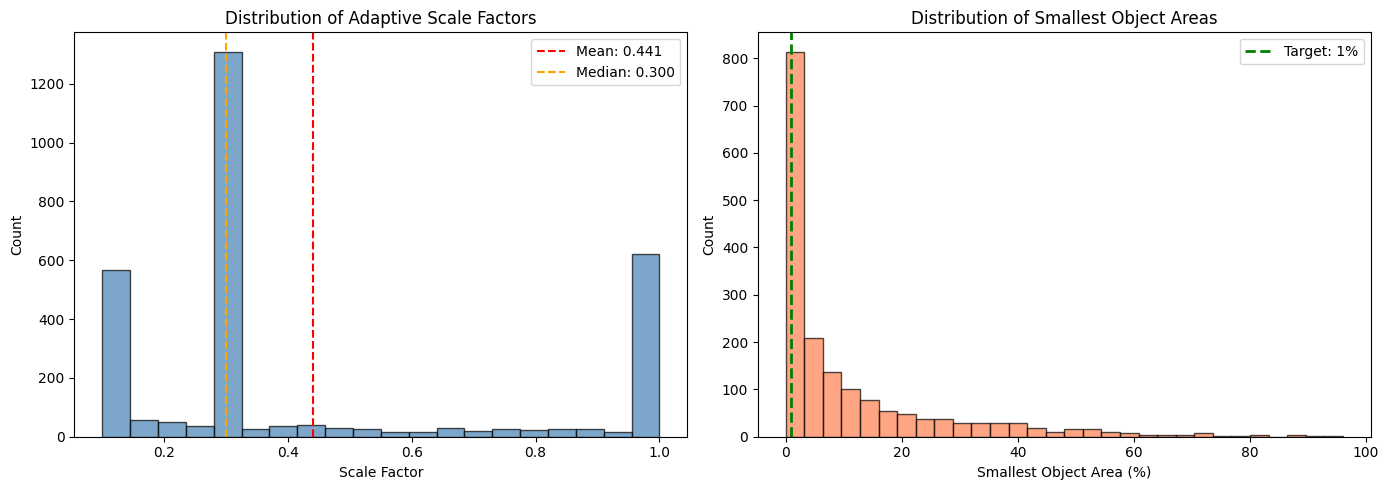

In [7]:
# Histogram of scale factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scale factor distribution
axes[0].hist(df['capped_scale'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['capped_scale'].mean(), color='red', linestyle='--', label=f'Mean: {df["capped_scale"].mean():.3f}')
axes[0].axvline(df['capped_scale'].median(), color='orange', linestyle='--', label=f'Median: {df["capped_scale"].median():.3f}')
axes[0].set_xlabel('Scale Factor')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Adaptive Scale Factors')
axes[0].legend()

# Smallest object area distribution (only samples with objects)
df_with_objects = df[df['smallest_area'] > 0]
axes[1].hist(df_with_objects['smallest_area_pct'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(1.0, color='green', linestyle='--', linewidth=2, label='Target: 1%')
axes[1].set_xlabel('Smallest Object Area (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Smallest Object Areas')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Scale factor by object class
class_stats = df.groupby('smallest_class').agg({
    'capped_scale': ['mean', 'std', 'min', 'max', 'count'],
    'smallest_area_pct': ['mean', 'min', 'max']
}).round(4)

print("Scale Factor by Smallest Object Class:")
class_stats

Scale Factor by Smallest Object Class:


capped_scale                             \
                                   mean     std     min  max count   
smallest_class                                                       
excavator                        0.6422  0.3989  0.1000  1.0   889   
none                             0.3000  0.0000  0.3000  0.3  1260   
rebar                            0.4970  0.3571  0.1000  1.0   266   
rule_1_violation                 0.3936  0.3602  0.1000  1.0   254   
rule_2_violation                 0.3723  0.3126  0.1000  1.0    20   
rule_3_violation                 0.9965  0.0168  0.9195  1.0    23   
rule_4_violation                 0.2778  0.2549  0.1000  1.0    13   
worker_with_white_hard_hat       0.3886  0.3544  0.1000  1.0   279   

                           smallest_area_pct               
                                        mean   min    max  
smallest_class                                             
excavator                            15.2349  0.03  96.04  
none                                  0.0000  0.00   0.00  
rebar                                 7.3610  0.20  69.12  
rule_1_violation                      6.6610  0.18  70.56  
rule_2_violation                      3.2510  0.40   9.20  
rule_3_violation                     32.5339  8.06  90.21  
rule_4_violation                      2.6254  0.65  10.60  
worker_with_white_hard_hat            5.5099  0.09  73.50

/tmp/ipykernel_1136391/4092021645.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=classes, patch_artist=True)


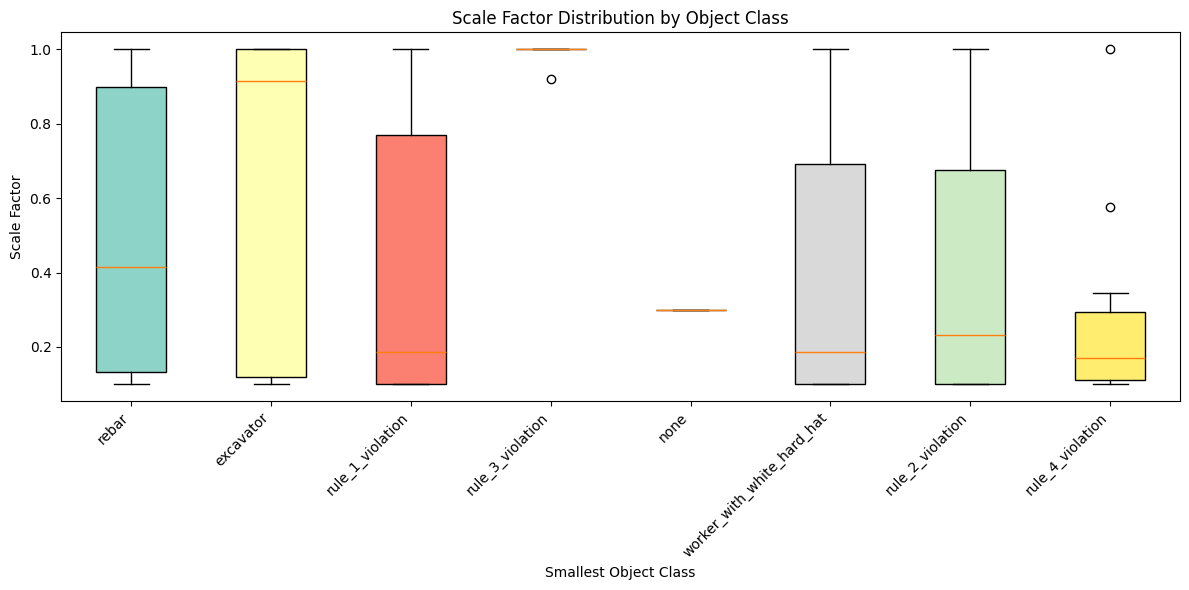

In [9]:
# Box plot by class
fig, ax = plt.subplots(figsize=(12, 6))

classes = df['smallest_class'].unique()
data_by_class = [df[df['smallest_class'] == c]['capped_scale'].values for c in classes]

bp = ax.boxplot(data_by_class, labels=classes, patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Smallest Object Class')
ax.set_ylabel('Scale Factor')
ax.set_title('Scale Factor Distribution by Object Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

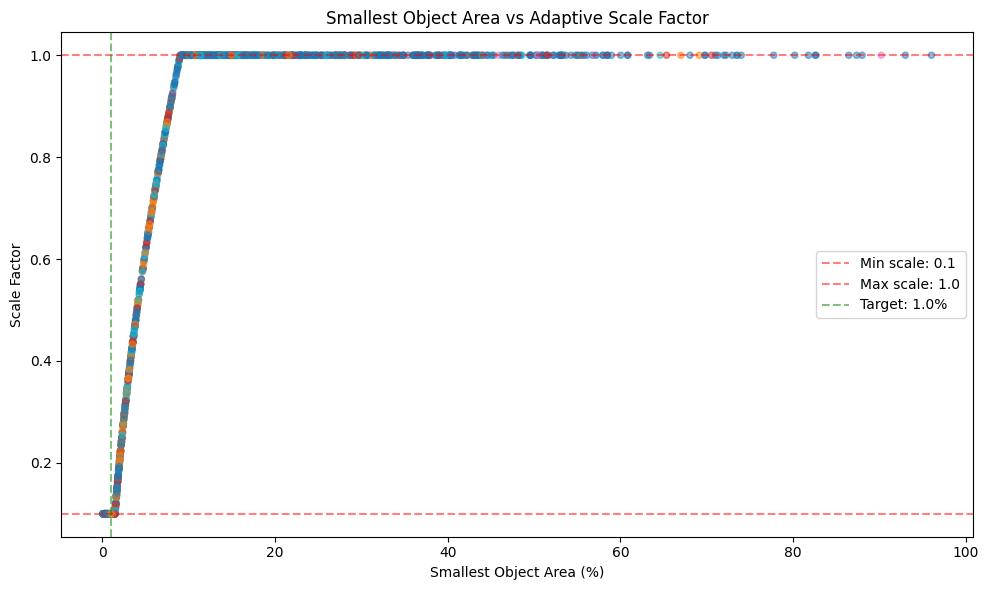

In [10]:
# Scatter plot: Object area vs Scale factor
fig, ax = plt.subplots(figsize=(10, 6))

df_with_obj = df[df['smallest_area'] > 0].copy()

scatter = ax.scatter(
    df_with_obj['smallest_area_pct'], 
    df_with_obj['capped_scale'],
    c=df_with_obj['smallest_class'].astype('category').cat.codes,
    cmap='tab10',
    alpha=0.5,
    s=20
)

ax.axhline(MIN_SCALE, color='red', linestyle='--', alpha=0.5, label=f'Min scale: {MIN_SCALE}')
ax.axhline(MAX_SCALE, color='red', linestyle='--', alpha=0.5, label=f'Max scale: {MAX_SCALE}')
ax.axvline(TARGET_PERCENT * 100, color='green', linestyle='--', alpha=0.5, label=f'Target: {TARGET_PERCENT*100}%')

ax.set_xlabel('Smallest Object Area (%)')
ax.set_ylabel('Scale Factor')
ax.set_title('Smallest Object Area vs Adaptive Scale Factor')
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# Analyze extreme cases
print("=" * 60)
print("Samples with HIGHEST scale (needs most expansion):")
print("=" * 60)
top_scale = df.nlargest(10, 'capped_scale')[['image_id', 'smallest_class', 'smallest_area_pct', 'capped_scale', 'num_objects']]
print(top_scale.to_string(index=False))

print("\n" + "=" * 60)
print("Samples with LOWEST scale (smallest objects already tiny):")
print("=" * 60)
# Filter to samples with objects
df_with_obj = df[df['smallest_area'] > 0]
low_scale = df_with_obj.nsmallest(10, 'smallest_area_pct')[['image_id', 'smallest_class', 'smallest_area_pct', 'capped_scale', 'num_objects']]
print(low_scale.to_string(index=False))

Samples with HIGHEST scale (needs most expansion):
image_id   smallest_class  smallest_area_pct  capped_scale  num_objects
 0000007 rule_3_violation              14.72           1.0            2
 0000014        excavator              37.80           1.0            1
 0000015            rebar              43.16           1.0            1
 0000022            rebar              15.84           1.0            1
 0000032        excavator              15.36           1.0            1
 0000042            rebar              11.70           1.0            1
 0000051        excavator              31.98           1.0            1
 0000069        excavator              30.87           1.0            1
 0000073        excavator              21.73           1.0            1
 0000079 rule_3_violation              33.32           1.0            1

Samples with LOWEST scale (smallest objects already tiny):
image_id             smallest_class  smallest_area_pct  capped_scale  num_objects
 0001279       

In [12]:
# Summary table: How many samples in each scale range
scale_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

df['scale_bin'] = pd.cut(df['capped_scale'], bins=scale_bins, labels=labels, right=False)

scale_distribution = df['scale_bin'].value_counts().sort_index()
scale_pct = (scale_distribution / len(df) * 100).round(1)

summary = pd.DataFrame({
    'Scale Range': scale_distribution.index,
    'Count': scale_distribution.values,
    'Percentage': scale_pct.values
})

print("\nScale Factor Distribution Summary:")
print(summary.to_string(index=False))
print(f"\nTotal: {len(df)} samples")


Scale Factor Distribution Summary:
Scale Range  Count  Percentage
      0-0.1      0         0.0
    0.1-0.2    639        21.3
    0.2-0.3     99         3.3
    0.3-0.4   1336        44.5
    0.4-0.5     76         2.5
    0.5-0.6     52         1.7
    0.6-0.7     46         1.5
    0.7-0.8     55         1.8
    0.8-0.9     60         2.0
    0.9-1.0    641        21.3

Total: 3004 samples


In [13]:
# Estimate canvas size after outpainting
# Assuming original image is 1024x768
ORIG_W, ORIG_H = 1024, 768

df['new_width'] = (ORIG_W * (1 + 2 * df['capped_scale'])).astype(int)
df['new_height'] = (ORIG_H * (1 + 2 * df['capped_scale'])).astype(int)
df['expansion_ratio'] = ((1 + 2 * df['capped_scale']) ** 2).round(2)

print(f"Assuming original image size: {ORIG_W}x{ORIG_H}")
print("\nCanvas Size After Outpainting:")
print(df[['image_id', 'capped_scale', 'new_width', 'new_height', 'expansion_ratio']].head(20).to_string(index=False))

print("\nExpansion Ratio Statistics:")
print(f"  Min: {df['expansion_ratio'].min():.2f}x")
print(f"  Max: {df['expansion_ratio'].max():.2f}x")
print(f"  Mean: {df['expansion_ratio'].mean():.2f}x")

Assuming original image size: 1024x768

Canvas Size After Outpainting:
image_id  capped_scale  new_width  new_height  expansion_ratio
 0000001      0.472111       1990        1493             3.78
 0000002      0.100000       1228         921             1.44
 0000005      0.100000       1228         921             1.44
 0000007      1.000000       3072        2304             9.00
 0000009      0.816245       2695        2021             6.93
 0000010      0.100000       1228         921             1.44
 0000013      0.300000       1638        1228             2.56
 0000014      1.000000       3072        2304             9.00
 0000015      1.000000       3072        2304             9.00
 0000017      0.221110       1476        1107             2.08
 0000018      0.300000       1638        1228             2.56
 0000019      0.387412       1817        1363             3.15
 0000020      0.100000       1228         921             1.44
 0000022      1.000000       3072        2304  

In [14]:
# Save scale info to JSON for pipeline
output_file = 'output_adaptive_test/scale_info.json'

import json
from pathlib import Path

Path('output_adaptive_test').mkdir(exist_ok=True)

scale_data = [
    {
        "image_id": r.image_id,
        "smallest_object_area": r.smallest_object_area,
        "smallest_object_class": r.smallest_object_class,
        "smallest_bbox": r.smallest_bbox,
        "calculated_scale": r.calculated_scale,
        "capped_scale": r.capped_scale,
        "all_objects": r.all_objects
    }
    for r in results
]

with open(output_file, 'w') as f:
    json.dump(scale_data, f, indent=2)

print(f"Saved scale info to: {output_file}")
print(f"Total records: {len(scale_data)}")

Saved scale info to: output_adaptive_test/scale_info.json
Total records: 3004


Samples with LOWEST scale factor (smallest objects):
image_id   smallest_class  smallest_area_pct  capped_scale
 0000002        excavator               0.55           0.1
 0000005 rule_1_violation               0.55           0.1
 0000010        excavator               0.27           0.1
 0000020        excavator               0.15           0.1
 0000023        excavator               1.28           0.1
 0000030            rebar               0.20           0.1


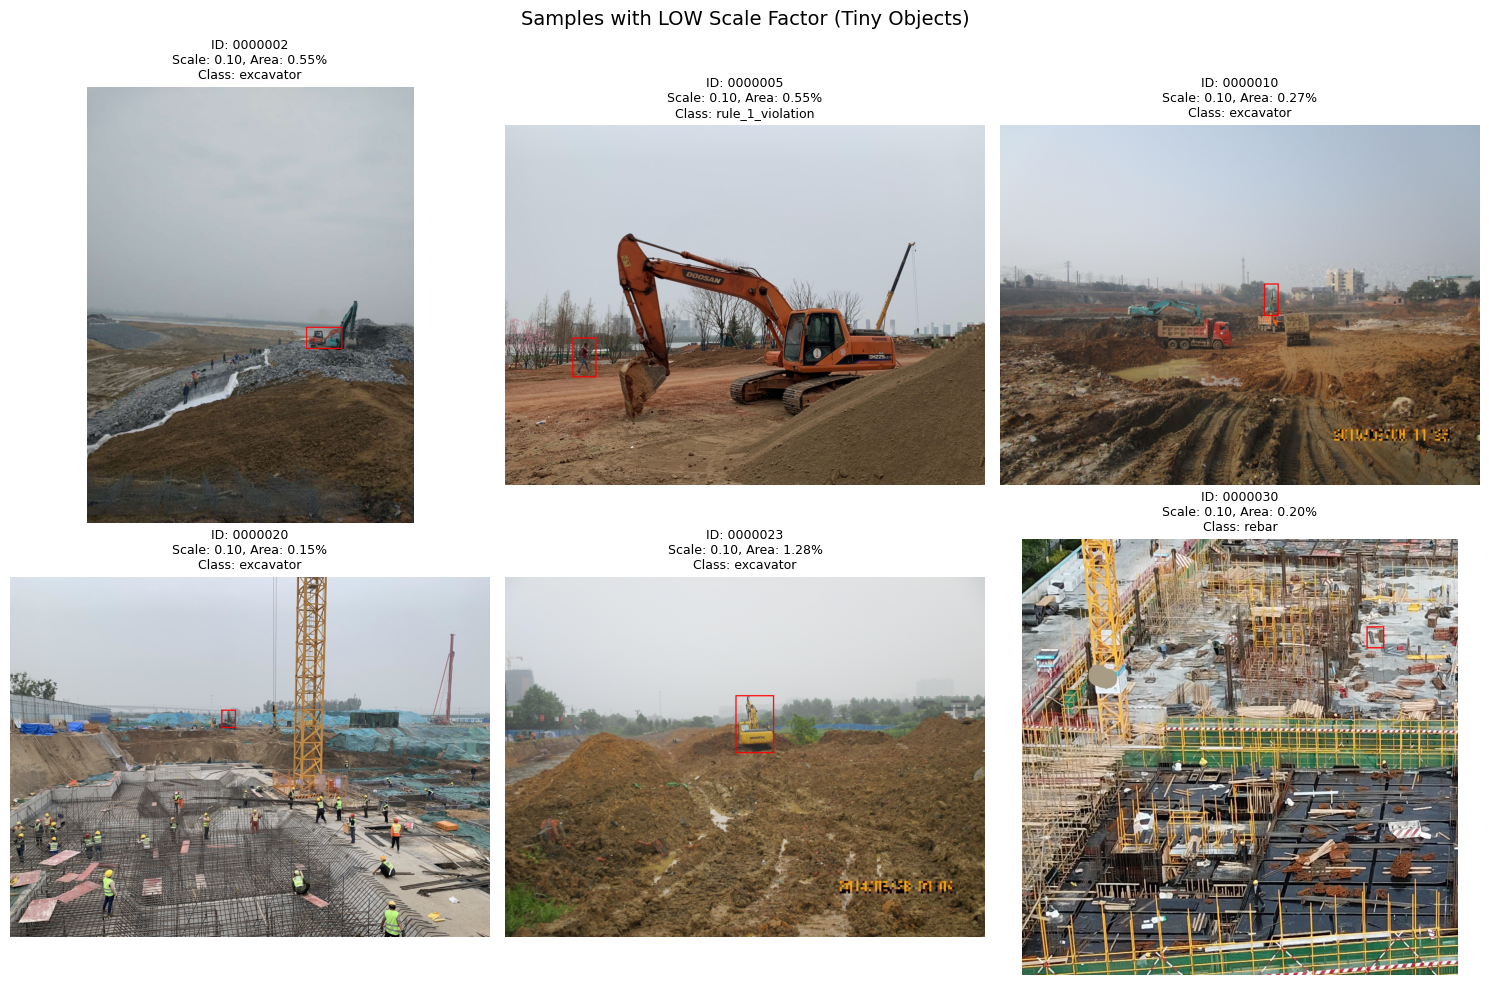

In [15]:
# Show samples with LOW scale factor (smallest objects already tiny)
import pyarrow as pa
from PIL import Image, ImageDraw
import io

# Load arrow file to get images
with open(ARROW_FILE, 'rb') as f:
    reader = pa.ipc.open_stream(f)
    table = reader.read_all()

# Get samples with low scale (excluding "none" class)
df_with_obj = df[df['smallest_class'] != 'none'].copy()
low_scale_samples = df_with_obj.nsmallest(6, 'capped_scale')

print("Samples with LOWEST scale factor (smallest objects):")
print(low_scale_samples[['image_id', 'smallest_class', 'smallest_area_pct', 'capped_scale']].to_string(index=False))

# Display images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(low_scale_samples.iterrows()):
    image_id = row['image_id']
    
    # Find index in table
    table_idx = None
    for i in range(table.num_rows):
        if str(table.column('image_id')[i].as_py()) == image_id:
            table_idx = i
            break
    
    if table_idx is None:
        continue
    
    # Load image
    image_data = table.column('image')[table_idx].as_py()
    if isinstance(image_data, dict) and 'bytes' in image_data:
        img = Image.open(io.BytesIO(image_data['bytes'])).convert('RGB')
    else:
        continue
    
    # Find the sample in results to get bbox info
    sample_result = next((r for r in results if r.image_id == image_id), None)
    
    # Draw bounding box if available
    if sample_result and sample_result.smallest_bbox:
        draw = ImageDraw.Draw(img)
        bbox = sample_result.smallest_bbox
        # Convert normalized to pixel coords
        x1 = int(bbox[0] * img.width)
        y1 = int(bbox[1] * img.height)
        x2 = int(bbox[2] * img.width)
        y2 = int(bbox[3] * img.height)
        draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"ID: {image_id}\nScale: {row['capped_scale']:.2f}, Area: {row['smallest_area_pct']:.2f}%\nClass: {row['smallest_class']}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Samples with LOW Scale Factor (Tiny Objects)', fontsize=14)
plt.tight_layout()
plt.show()

Samples with HIGHEST scale factor (largest objects needing expansion):
image_id   smallest_class  smallest_area_pct  capped_scale
 0000007 rule_3_violation              14.72           1.0
 0000014        excavator              37.80           1.0
 0000015            rebar              43.16           1.0
 0000022            rebar              15.84           1.0
 0000032        excavator              15.36           1.0
 0000042            rebar              11.70           1.0


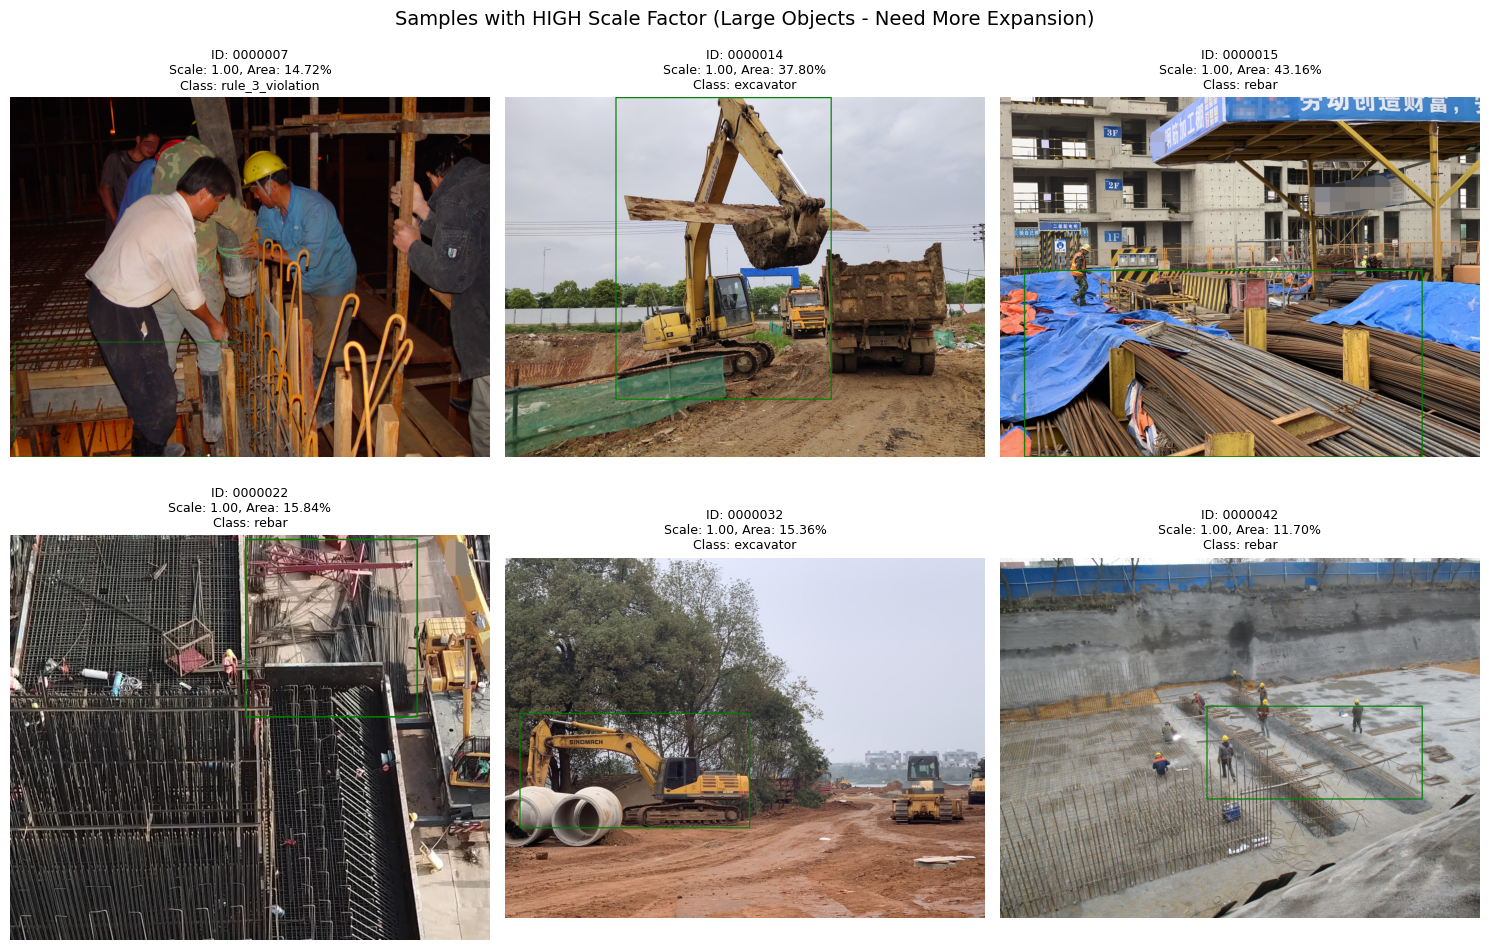

In [16]:
# Show samples with HIGH scale factor (large objects that need more expansion)
high_scale_samples = df_with_obj.nlargest(6, 'capped_scale')

print("Samples with HIGHEST scale factor (largest objects needing expansion):")
print(high_scale_samples[['image_id', 'smallest_class', 'smallest_area_pct', 'capped_scale']].to_string(index=False))

# Display images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(high_scale_samples.iterrows()):
    image_id = row['image_id']
    
    # Find index in table
    table_idx = None
    for i in range(table.num_rows):
        if str(table.column('image_id')[i].as_py()) == image_id:
            table_idx = i
            break
    
    if table_idx is None:
        continue
    
    # Load image
    image_data = table.column('image')[table_idx].as_py()
    if isinstance(image_data, dict) and 'bytes' in image_data:
        img = Image.open(io.BytesIO(image_data['bytes'])).convert('RGB')
    else:
        continue
    
    # Find the sample in results to get bbox info
    sample_result = next((r for r in results if r.image_id == image_id), None)
    
    # Draw bounding box if available
    if sample_result and sample_result.smallest_bbox:
        draw = ImageDraw.Draw(img)
        bbox = sample_result.smallest_bbox
        # Convert normalized to pixel coords
        x1 = int(bbox[0] * img.width)
        y1 = int(bbox[1] * img.height)
        x2 = int(bbox[2] * img.width)
        y2 = int(bbox[3] * img.height)
        draw.rectangle([x1, y1, x2, y2], outline='green', width=3)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"ID: {image_id}\nScale: {row['capped_scale']:.2f}, Area: {row['smallest_area_pct']:.2f}%\nClass: {row['smallest_class']}", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Samples with HIGH Scale Factor (Large Objects - Need More Expansion)', fontsize=14)
plt.tight_layout()
plt.show()